# Thematic Alignment in Scientific Journals

Compact notebook for running the `journal_alignment` package and inspecting the main outputs. The implementation stays in `src/journal_alignment/`; this notebook keeps only the orchestration and result previews.

## 1. Setup

Run this notebook from the repository root (`nlp/`) so the default project paths resolve correctly. Full CSV outputs are saved under `reports/tables/`; the notebook shows compact previews only.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 8)
pd.set_option("display.max_colwidth", 80)

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from journal_alignment import ProjectConfig
from journal_alignment.pipeline import AlignmentPipeline


def preview_table(table, columns=None, rows=5):
    """Return a compact preview without modifying the underlying table."""
    selected_columns = list(columns) if columns is not None else list(table.columns)
    selected_columns = [column for column in selected_columns if column in table.columns]
    return table.loc[:, selected_columns].head(rows).copy()

## 2. Load configuration

The default configuration expects the raw PubMed CSV and Aims & Scope text file under `data/raw/`.

In [2]:
config = ProjectConfig()

config_summary = pd.DataFrame(
    {
        "setting": [
            "articles_path",
            "aims_scope_path",
            "results_dir",
            "figures_dir",
            "tables_dir",
            "model_name",
            "top_n",
        ],
        "value": [
            config.articles_path,
            config.aims_scope_path,
            config.results_dir,
            config.figures_dir,
            config.tables_dir,
            config.model_name,
            config.top_n,
        ],
    }
)
display(preview_table(config_summary, rows=len(config_summary)))

,setting,value
0,articles_path,..\data\raw\articles_pubmed.csv
1,aims_scope_path,..\data\raw\aims_scope.txt
2,results_dir,..\data\results
3,figures_dir,..\reports\figures
4,tables_dir,..\reports\tables
5,model_name,sentence-transformers/all-MiniLM-L6-v2
6,top_n,10


## 3. Run pipeline

The pipeline loads the inputs, computes alignment scores, saves CSV outputs, and creates plots.

In [3]:
pipeline = AlignmentPipeline(config)
results = pipeline.run()

available_outputs = pd.DataFrame({"output": list(results.keys())})
display(preview_table(available_outputs, rows=len(available_outputs)))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (365 > 256). Running this sequence through the model will result in indexing errors


,output
0,alignment_scores
1,summary_statistics
2,yearly_alignment
3,top_aligned_articles
4,least_aligned_articles
5,outlier_articles
6,chunk_count_report
7,bertopic_topic_summary
8,bertopic_topic_diagnostics
9,bertopic_topics_over_time


## 4. Article-level scores

The main output contains one row per article. The preview below keeps the identifiers and the two alignment measures; the complete table remains saved as CSV.

In [4]:
article_scores = results["alignment_scores"]
article_columns = [
    "pmid",
    "title",
    "year",
    "alignment_score",
    "tfidf_alignment_score",
    "is_outlier",
]
display(preview_table(article_scores, article_columns, rows=5))

,pmid,title,year,alignment_score,tfidf_alignment_score,is_outlier
0,41480514,"Nanofiber scaffold for bone tissue engineering: Mechanism, challenge and fut...",2025,0.297676,0.090473,False
1,41480513,Biodegradable materials: Applications and advances of magnesium alloys in bo...,2025,0.236581,0.068943,False
2,41480512,One-year follow-up of conservative and surgical treatment results for patien...,2025,0.310352,0.090380,False
3,41480511,Halo gravity traction for pediatric scoliosis and kyphoscoliosis: A review o...,2025,0.410242,0.093701,False
4,41480510,Comparison of two fixation techniques of olecranon osteotomy after reconstru...,2025,0.395579,0.060522,False


## 5. Yearly scores

The yearly table aggregates article-level alignment scores by publication year.

In [5]:
display(preview_table(results["yearly_alignment"], rows=12))

,year,count,mean,median,std,min,max
0,2015,119,0.338791,0.341961,0.067086,0.168484,0.497184
1,2016,111,0.323217,0.327908,0.082049,0.034925,0.520259
2,2017,125,0.328059,0.328879,0.078364,0.106946,0.581535
3,2018,40,0.341620,0.344167,0.063387,0.198016,0.462076
4,2019,48,0.345849,0.342038,0.070041,0.199846,0.497625
5,2020,64,0.355588,0.346904,0.085036,0.184632,0.557726
6,2021,98,0.358014,0.347586,0.095821,0.156974,0.747456
7,2022,102,0.349066,0.350868,0.077663,0.139016,0.560629
8,2023,90,0.342621,0.339698,0.079988,0.126759,0.642153
9,2024,140,0.345036,0.341992,0.081448,0.085009,0.592074


## 6. Top and bottom articles

These previews show the highest and lowest scoring articles according to the embedding alignment score.

In [6]:
ranking_columns = ["pmid", "title", "year", "alignment_score", "tfidf_alignment_score"]

top_articles = results["top_aligned_articles"]
bottom_articles = results["least_aligned_articles"]

print("Top aligned articles")
display(preview_table(top_articles, ranking_columns, rows=5))

print("Least aligned articles")
display(preview_table(bottom_articles, ranking_columns, rows=5))

Top aligned articles


,pmid,title,year,alignment_score,tfidf_alignment_score
0,33614424,New Year's greeting and overview of World Journal of Orthopedics in 2021.,2021,0.747456,0.231259
1,33816143,Bibliometric analysis of research on the effects of human immunodeficiency v...,2021,0.675017,0.121479
2,37662667,Scientific publications on orthopedic surgery from three major East Asian co...,2023,0.642153,0.149816
3,39473512,Research trends in exercise therapy for the treatment of pain in postmenopau...,2024,0.592074,0.180066
4,34754830,Surgical treatment of metastatic bone disease of the distal extremities.,2021,0.582920,0.154672


Least aligned articles


,pmid,title,year,alignment_score,tfidf_alignment_score
0,28032039,Glomus tumors of the fingers: Expression of vascular endothelial growth factor.,2016,0.034925,0.069548
1,38596192,New method of local adjuvant therapy with bicarbonate Ringer's solution for ...,2024,0.085009,0.056447
2,29312846,Role of fast-setting cements in arthroplasty: A comparative analysis of char...,2017,0.106946,0.053876
3,40547242,Arthroscopic management of a rare free-edge medial meniscal cyst: A case rep...,2025,0.123912,0.063870
4,37970623,Vancomycin flushing syndrome in orthopaedic practice: A case report.,2023,0.126759,0.075768


## 7. Saved visualizations

The pipeline saves standard plots under `reports/figures/`. The notebook displays the figures without printing every file path.

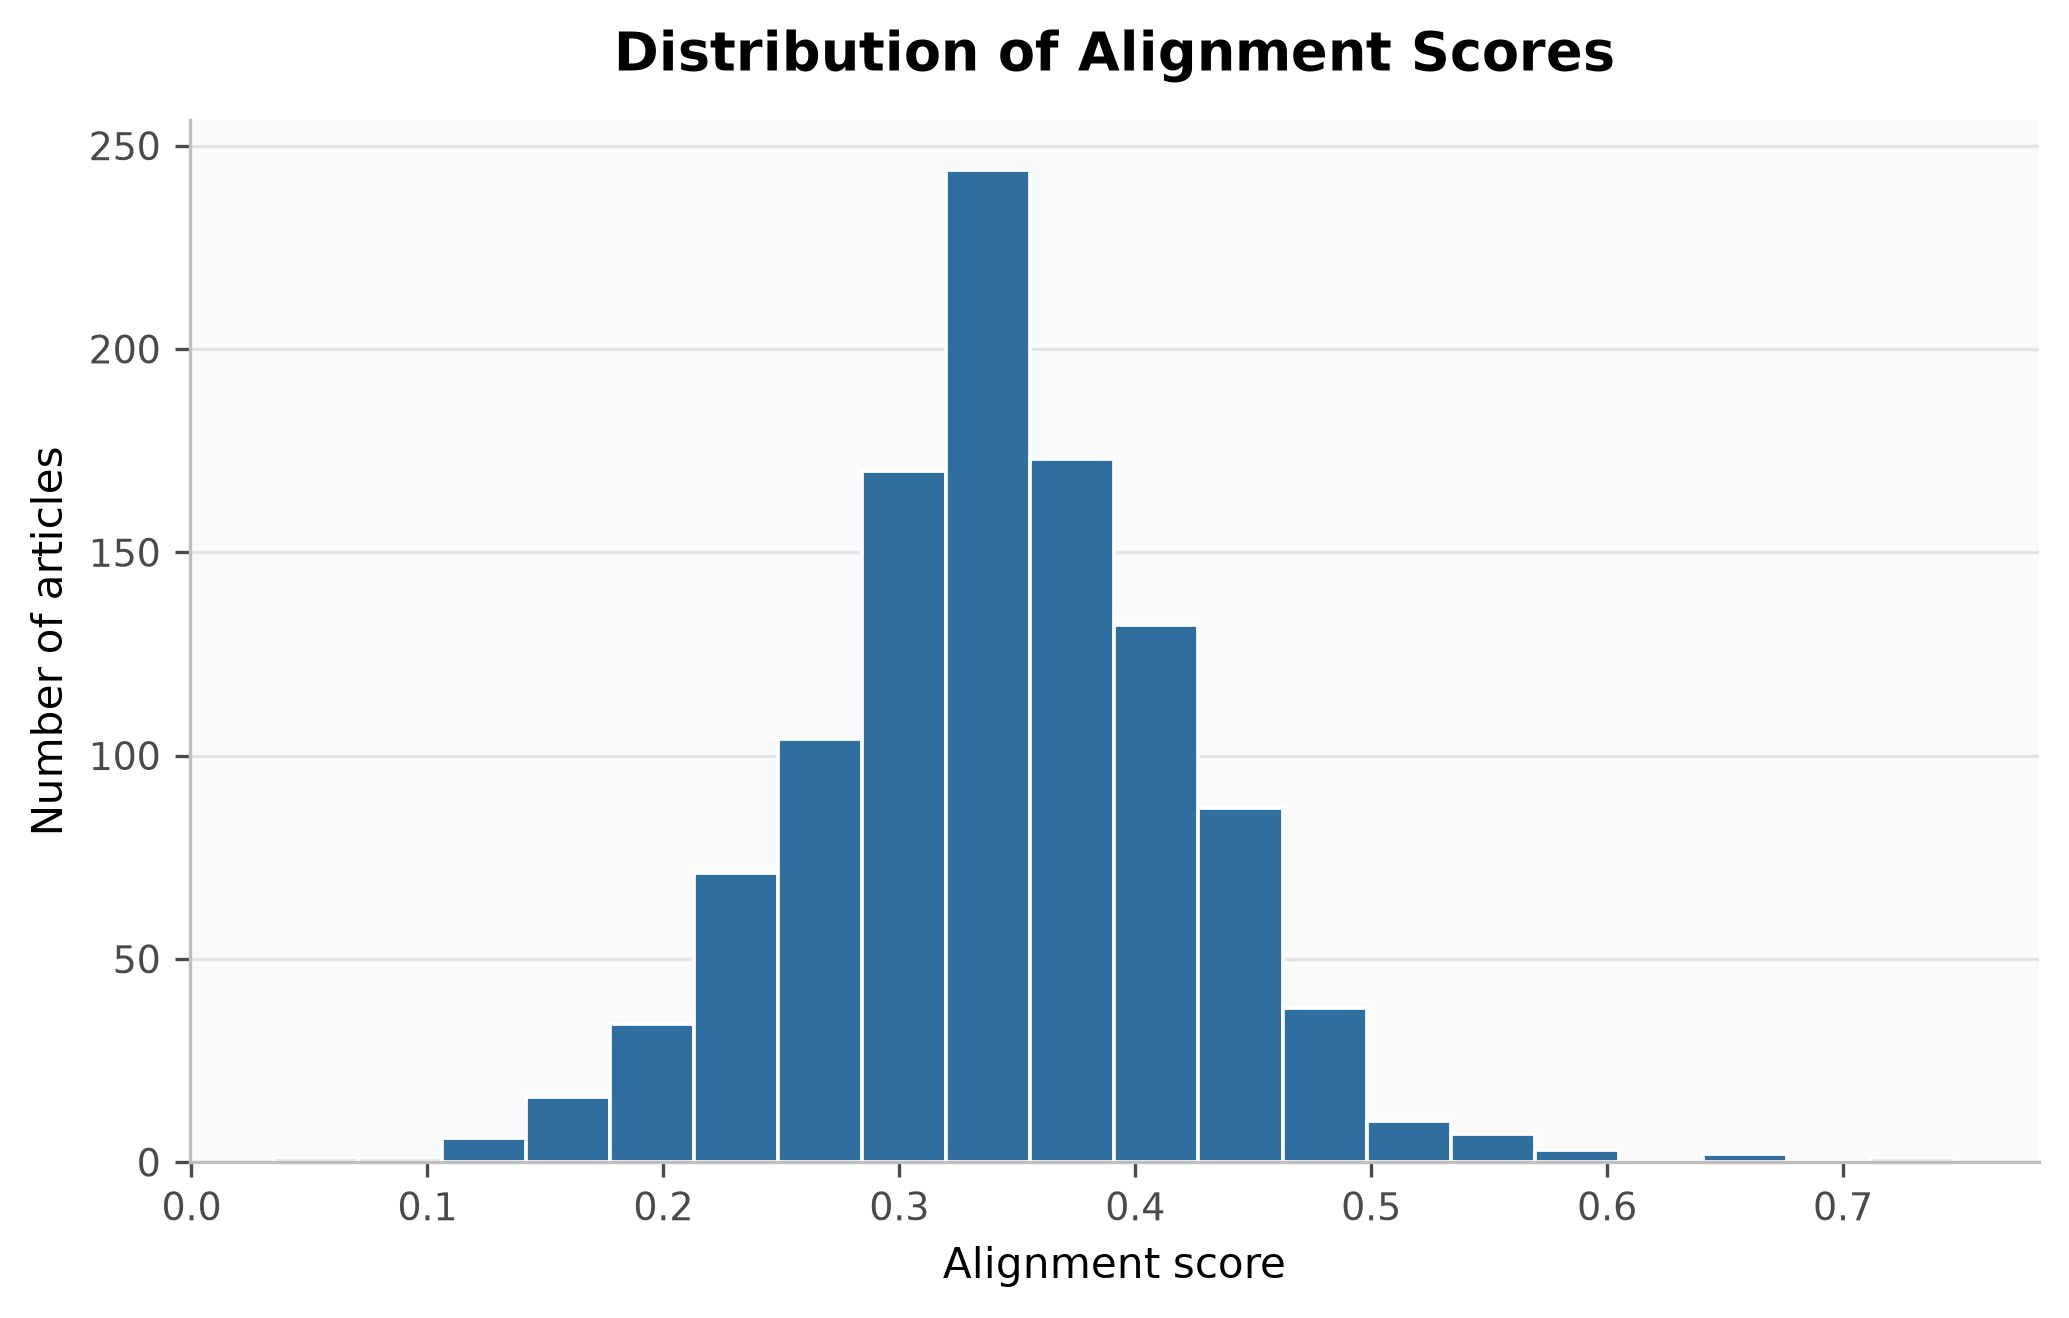

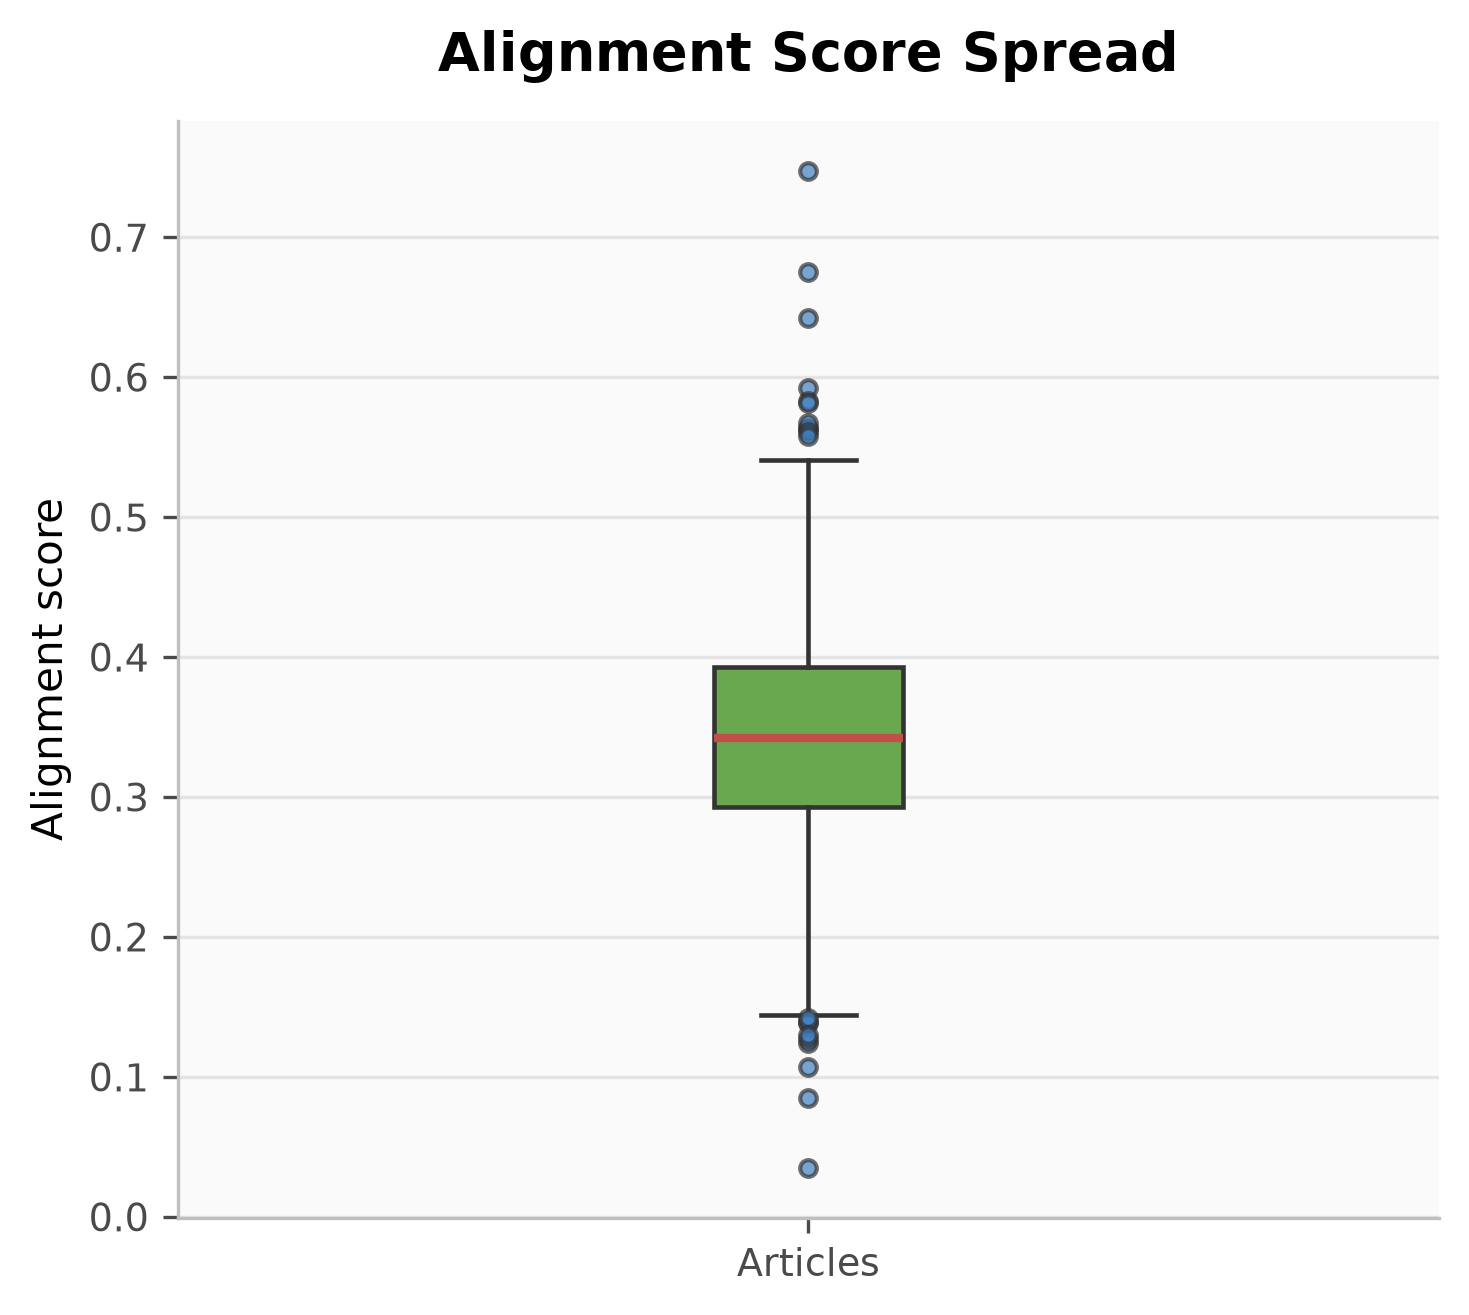

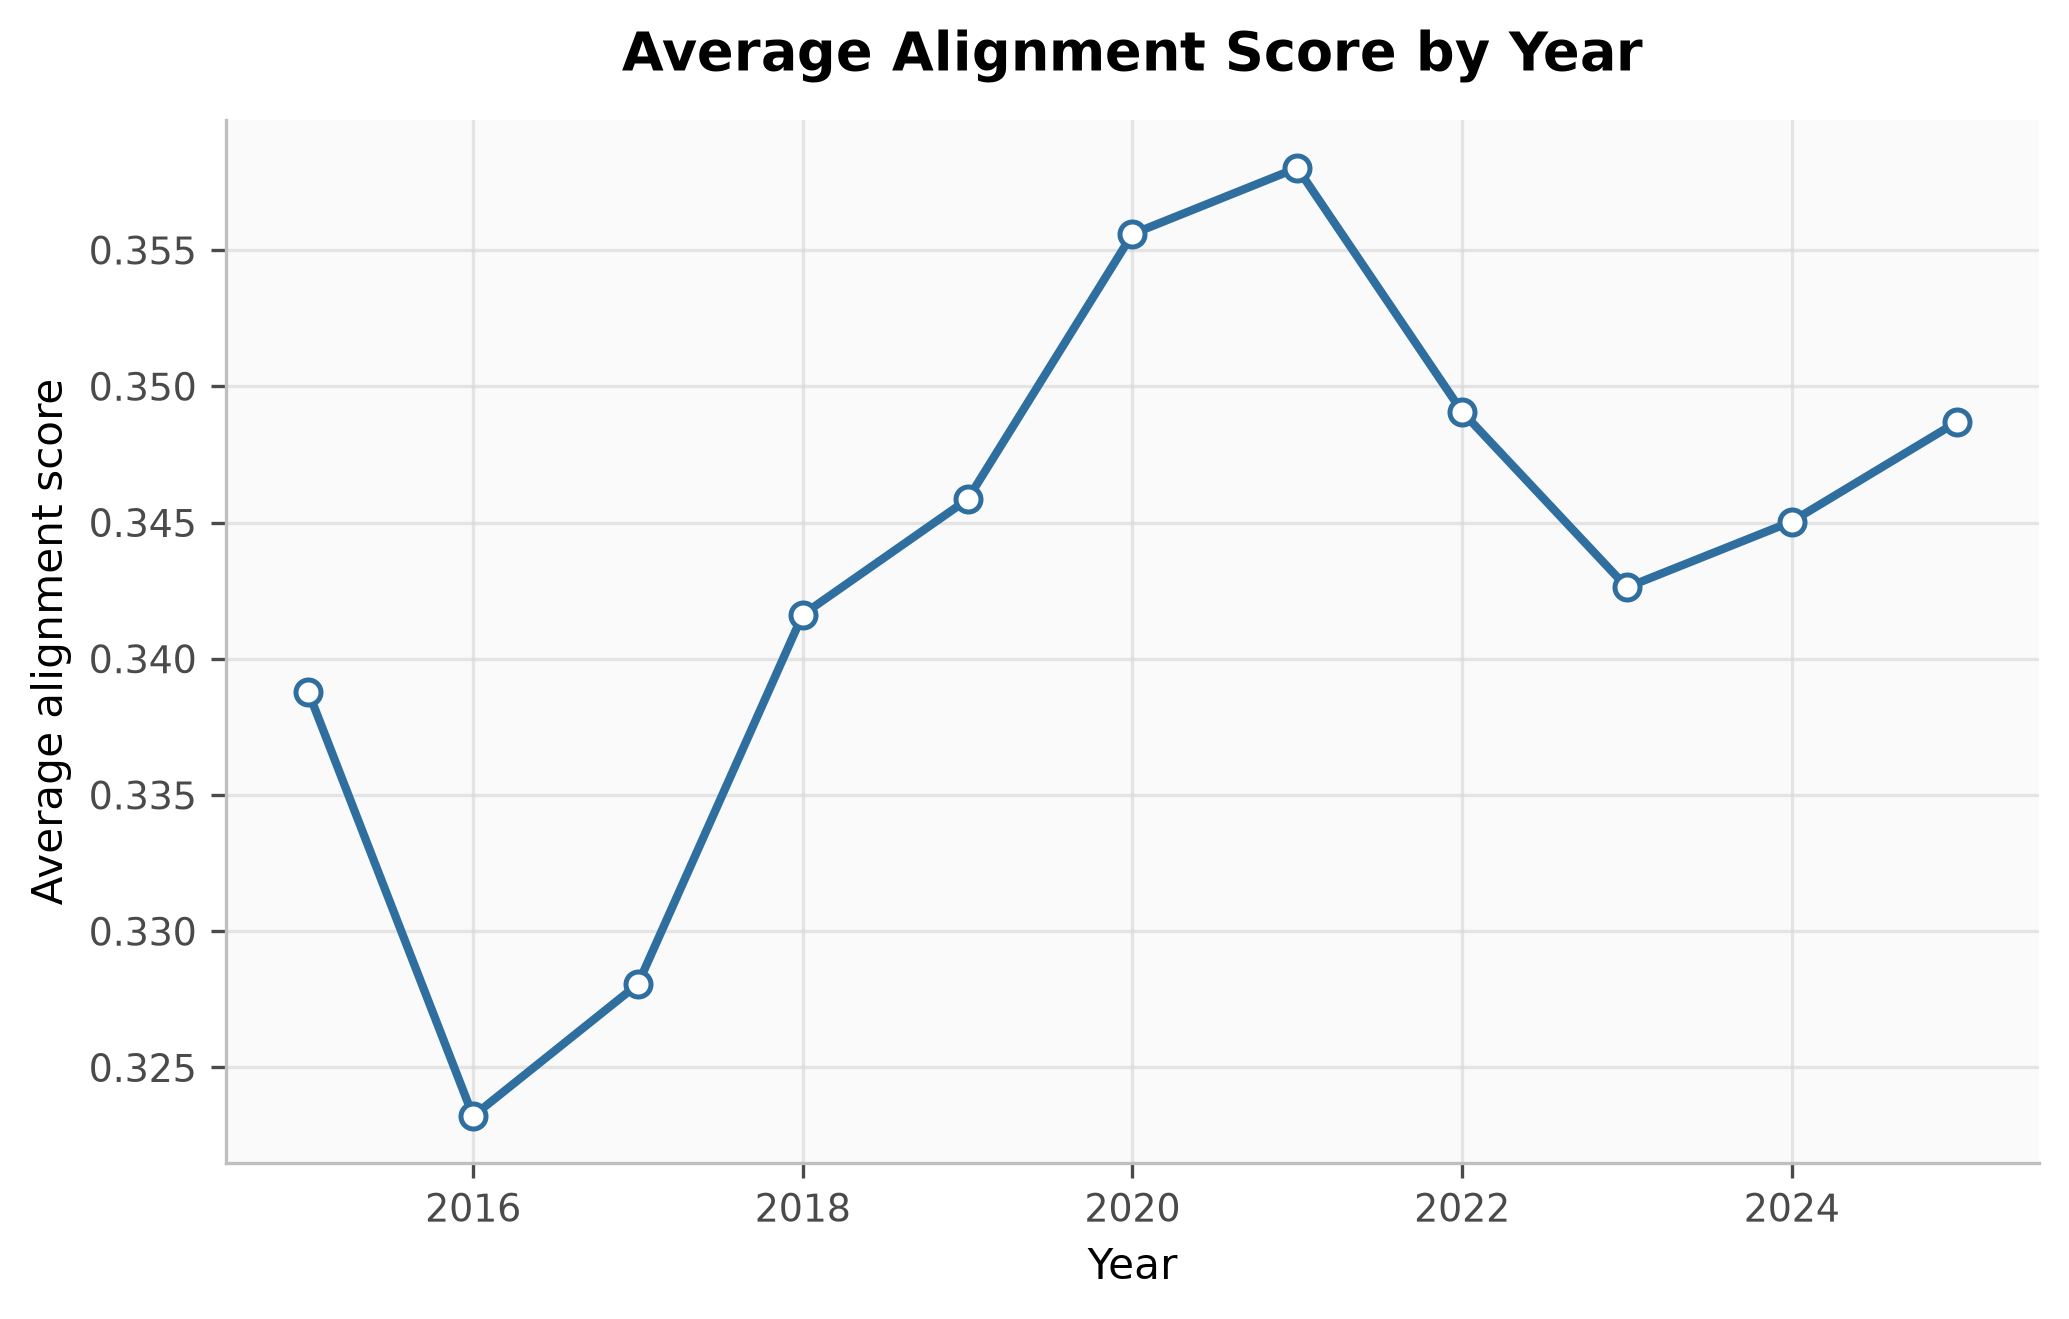

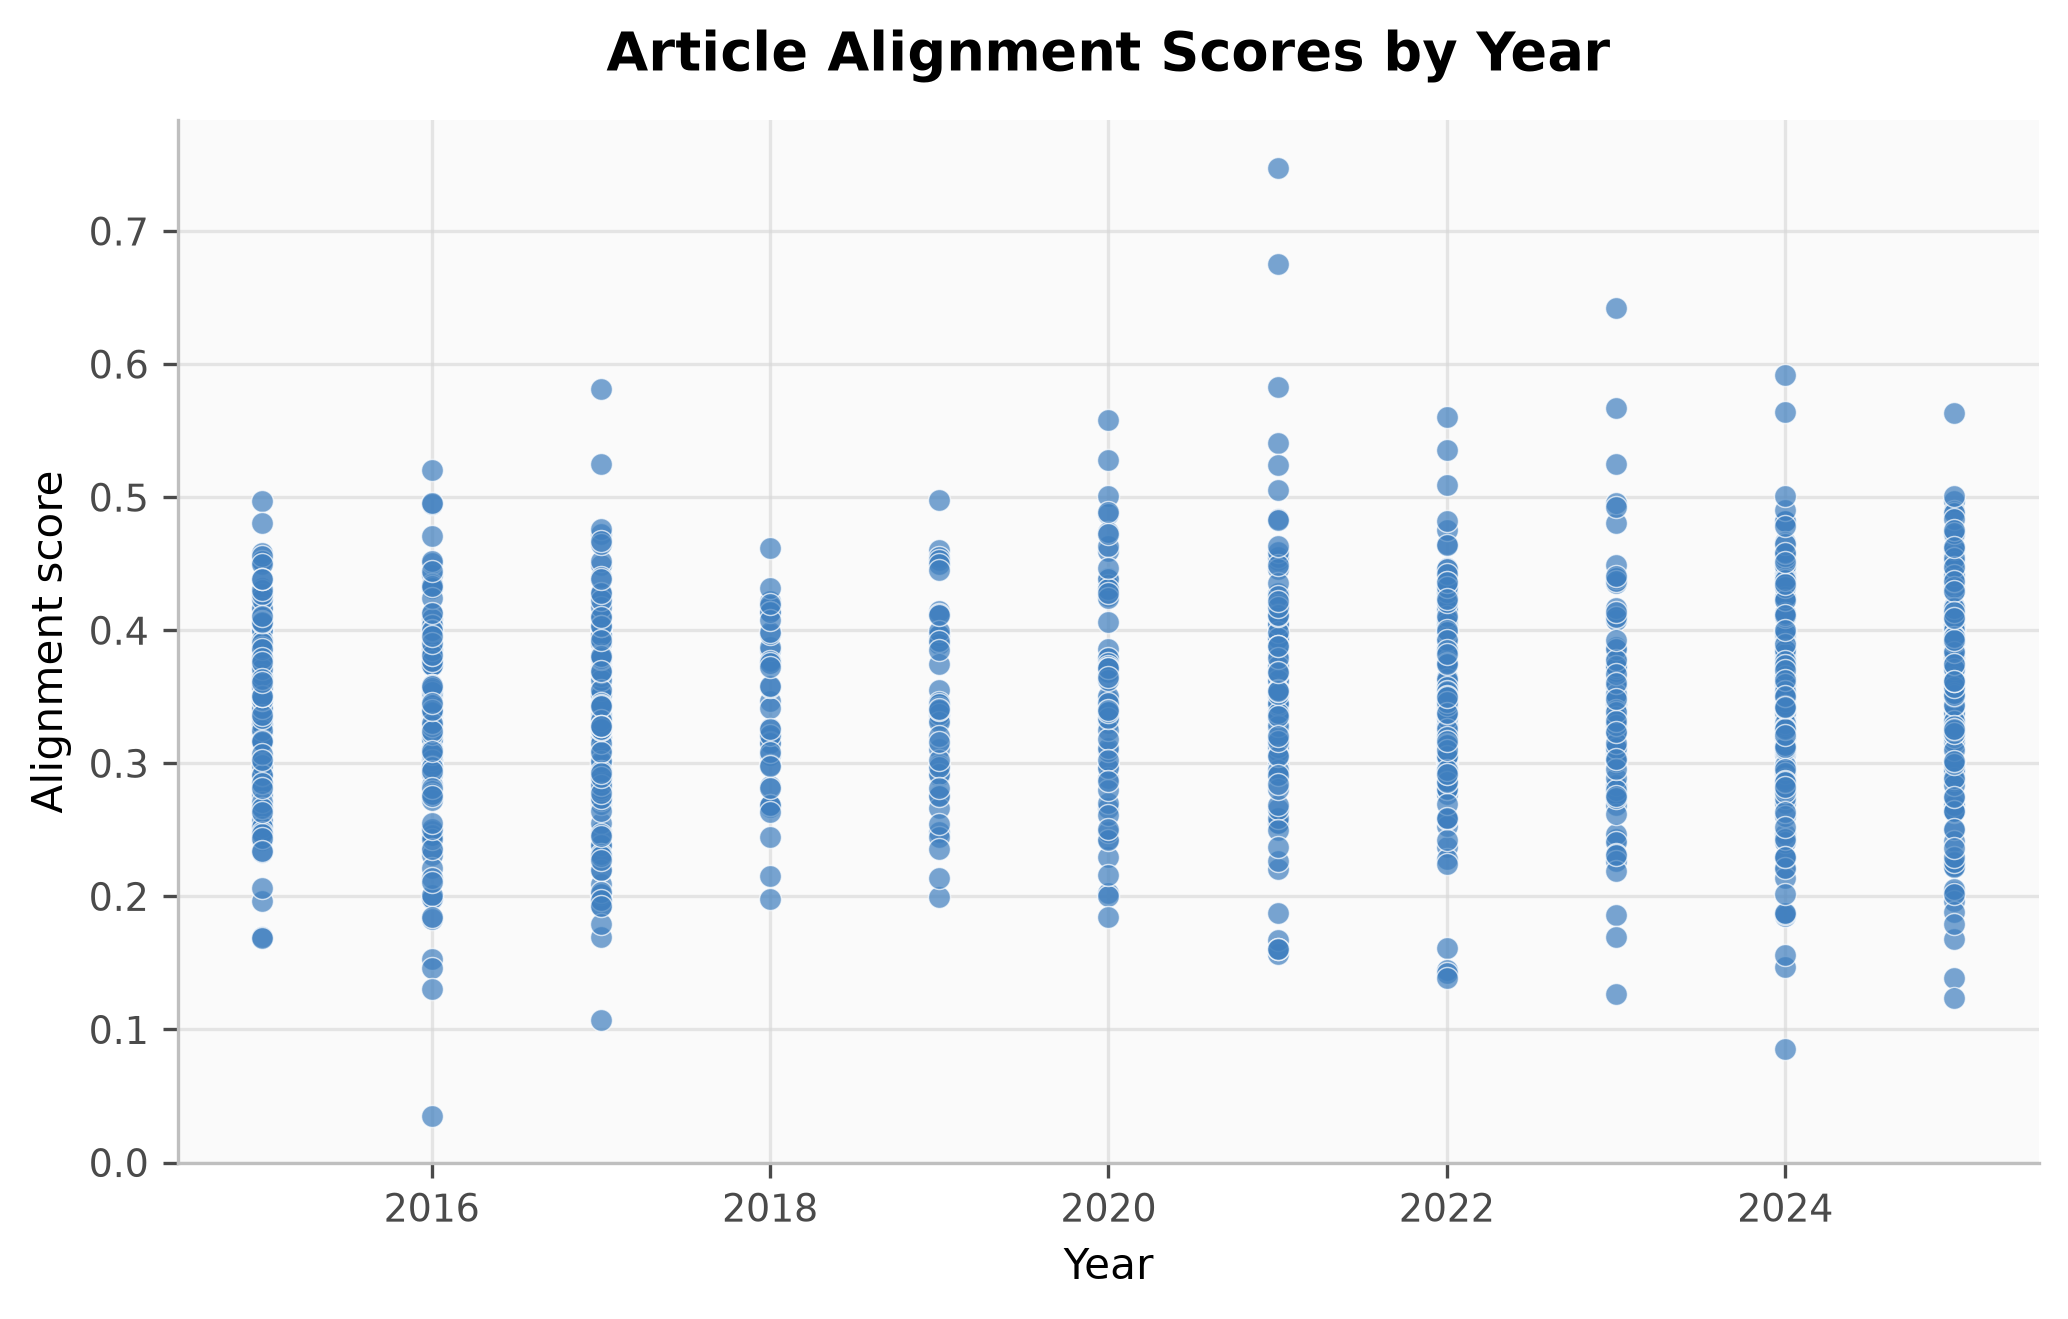

In [7]:
figure_names = [
    "alignment_histogram.png",
    "alignment_boxplot.png",
    "alignment_by_year.png",
    "article_scores_by_year.png",
]

for figure_name in figure_names:
    figure_path = config.figures_dir / figure_name
    if figure_path.exists():
        display(Image(filename=str(figure_path)))
    else:
        print(f"{figure_name}: plot not found. Run the pipeline cell first.")

## 8. BERTopic diagnostics

These previews use BERTopic as a complementary corpus-structure check, not as a replacement for the cosine alignment score. Full diagnostic tables remain in `reports/tables/`.

chunk_count_report.csv: 1 rows, 8 columns


,text_label,total_texts,single_chunk_texts,multi_chunk_texts,multi_chunk_share,max_chunks_for_one_text,model_max_tokens,effective_chunk_token_limit
0,abstracts,1100,295,805,0.731818,5,256,254


bertopic_topic_summary.csv: 10 rows, 3 columns


,topic_id,top_5_keywords,article_count
0,-1,patients; bone; treatment; results; methods,267
1,0,fractures; patients; hip; fracture; femoral,239
2,1,knee; patients; tka; group; bone,193
3,2,spinal; pain; lumbar; patients; spine,114
4,3,infection; pji; antibiotic; patients; infections,77


bertopic_topic_diagnostics.csv: 6 rows, 2 columns


,metric,value
0,noise_cluster_size,267
1,topics_excluding_noise,9
2,distinct_years,11
3,topics_over_time_nr_bins,11
4,umap_random_state,6


outlier_topic_assignments.csv: 47 rows, 11 columns


,pmid,title,year,alignment_score,outlier_direction,bertopic_topic_label
0,41480508,Advancing global orthopedic research through culturally adapted outcome meas...,2025,0.562977,high_alignment_outlier,Noise
1,41181042,Emerging neural modulation techniques for the management of phantom limb pai...,2025,0.179597,low_alignment_outlier,"Topic 2: spinal, pain, lumbar"
2,40547242,Arthroscopic management of a rare free-edge medial meniscal cyst: A case rep...,2025,0.123912,low_alignment_outlier,"Topic 7: acl, reconstruction, meniscal"
3,40496261,Long non-coding RNA GAS5 promotes neuronal apoptosis in spinal cord injury v...,2025,0.168156,low_alignment_outlier,"Topic 1: knee, patients, tka"
4,39850033,Role of neurogenic inflammation in intervertebral disc degeneration.,2025,0.138327,low_alignment_outlier,"Topic 2: spinal, pain, lumbar"


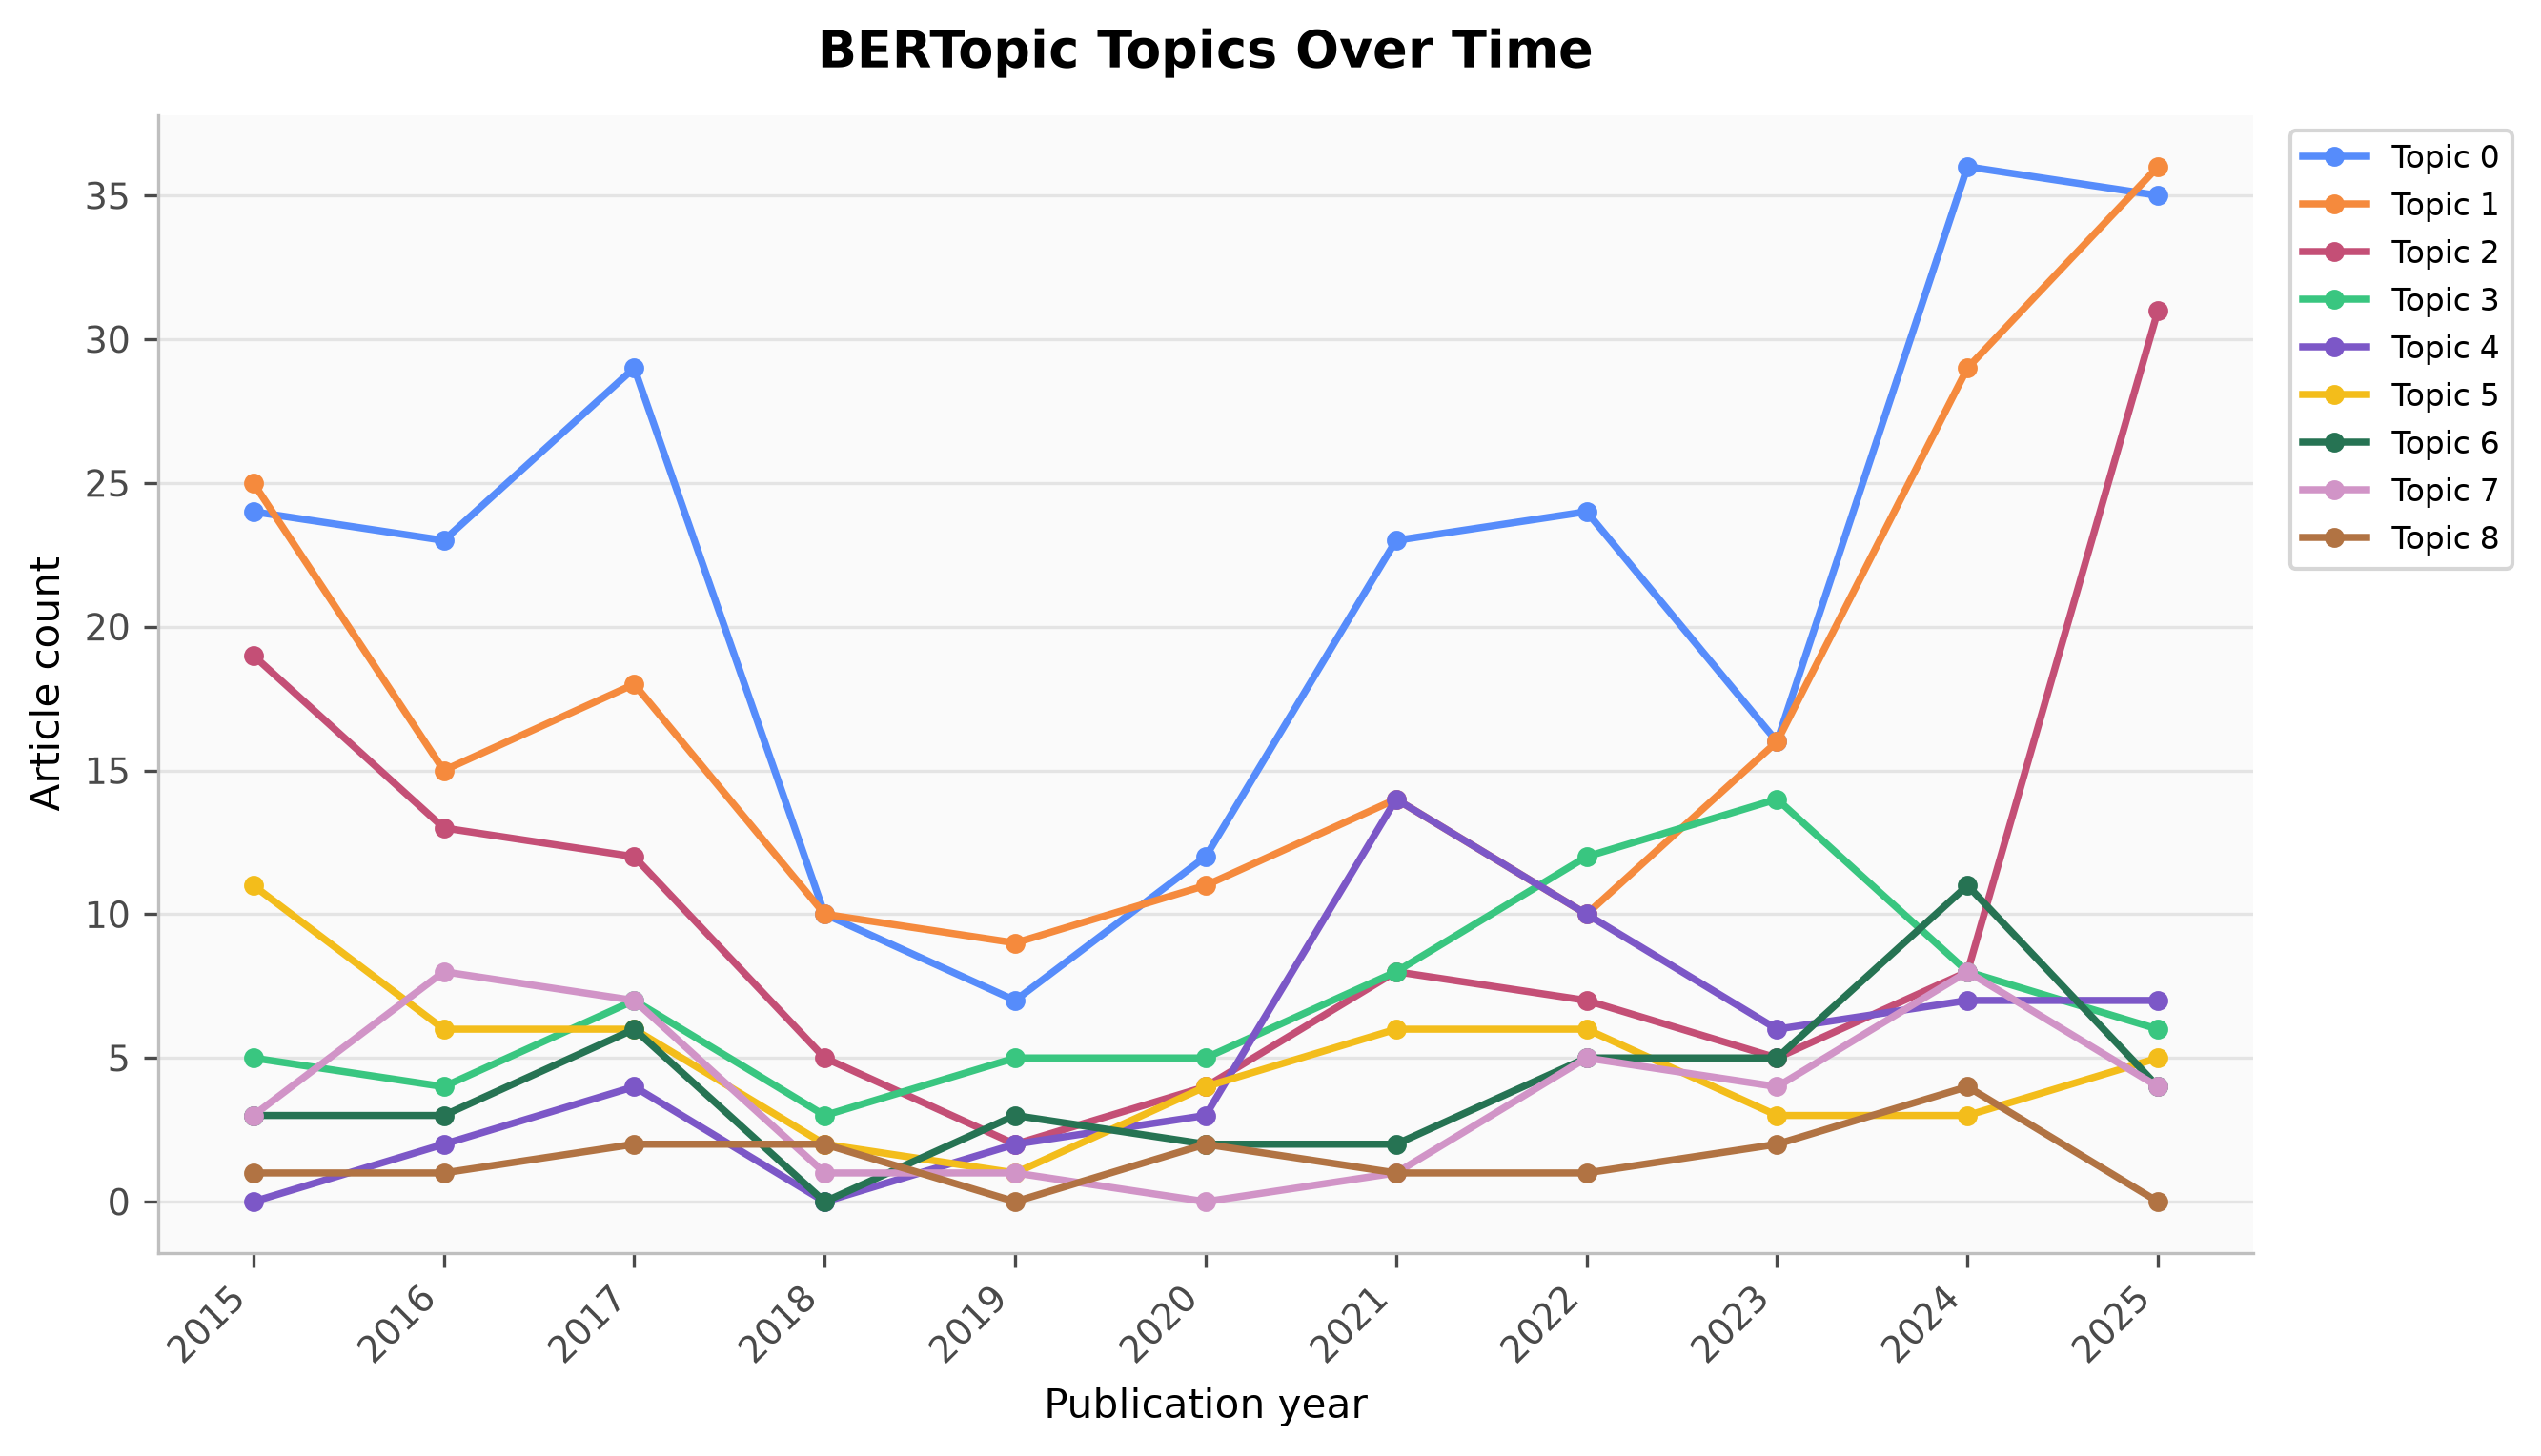

In [8]:
topic_table_previews = {
    "chunk_count_report.csv": None,
    "bertopic_topic_summary.csv": ["topic_id", "top_5_keywords", "article_count"],
    "bertopic_topic_diagnostics.csv": None,
    "outlier_topic_assignments.csv": [
        "pmid",
        "title",
        "year",
        "alignment_score",
        "outlier_direction",
        "bertopic_topic_label",
    ],
}

for table_name, columns in topic_table_previews.items():
    table_path = config.tables_dir / table_name
    if table_path.exists():
        table = pd.read_csv(table_path)
        print(f"{table_name}: {len(table)} rows, {len(table.columns)} columns")
        display(preview_table(table, columns, rows=5))
    else:
        print(f"{table_name}: table not found. Run the pipeline with BERTopic enabled.")

topics_over_time_name = "bertopic_topics_over_time.png"
topics_over_time_path = config.figures_dir / topics_over_time_name
if topics_over_time_path.exists():
    display(Image(filename=str(topics_over_time_path)))
else:
    print(f"{topics_over_time_name}: plot not found. Run the pipeline with BERTopic enabled.")